# Desafio Final: Detecção de Fraude em Cartão de Crédito

**Aluno:** Johnny da Silva Xavier

**Web Academy** - **ICOMP**

Este notebook aplica todo o fluxo de trabalho de Machine Learning aprendido na prática a um novo problema: a detecção de fraudes em transações de cartão de crédito. Utilizaremos o dataset clássico do Kaggle (*Credit Card Fraud Detection*), lidando com um cenário de dados altamente desbalanceados.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### 1. Carregamento e Exploração Inicial dos Dados

Para baixar os dados, acesse o [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), baixe o arquivo `creditcard.csv` e faça o upload para o seu ambiente do Google Colab (ou coloque na pasta `./data/` se estiver rodando localmente).

In [ ]:
# Carregamento do dataset
DATA_PATH = './data/creditcard.csv'

try:
  df_fraud = pd.read_csv(DATA_PATH)
  print("Dataset de fraude carregado com sucesso!")
except FileNotFoundError:
  print("Arquivo não encontrado. Faça o upload de 'creditcard.csv' para o diretório atual.")

# Verificação estrutural inicial

display(df_fraud.head())
df_fraud.info()
display(df_fraud.describe())

# Análise da distribuição do alvo (Class)

print("\nDistribuição da variável alvo (Class em %):")
print(df_fraud['Class'].value_counts(normalize=True) * 100)

Dataset de fraude carregado com sucesso!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000



Distribuição da variável alvo (Class em %):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


### 2. Preparação e Engenharia de Features

As features de V1 a V28 já passaram por transformação PCA para proteger a privacidade dos dados. A coluna `Amount` (valor da transação), no entanto, está na escala original e precisa ser padronizada para que a Regressão Logística funcione de forma adequada.

In [18]:
# Selecionando as features

features = [col for col in df_fraud.columns if col.startswith('V')] + ['Amount']

X = df_fraud[features].copy()
y = df_fraud['Class'].copy()

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)

Dimensões de X: (284807, 29)
Dimensões de y: (284807,)


### 3. Divisão dos Dados com Estratificação

Como a fraude é um evento extremamente raro (menos de 0,2% das transações), é obrigatório utilizar a divisão estratificada (`stratify=y`) para garantir que a proporção de fraudes seja igual tanto no conjunto de treino quanto no de teste. Antes disso, filtramos eventuais valores nulos para evitar erros de execução.

In [23]:
# Removendo linhas que possuem valores ausentes
mask = ~(X.isnull().any(axis=1) | y.isnull())

X = X[mask]
y = y[mask]

# Divisão dos dados em treino e teste
# O stratify mantém a mesma proporção de fraudes
# nos dois conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Padronizando apenas a coluna Amount
# O scaler aprende os valores APENAS do conjunto de treino

scaler = StandardScaler()

X_train['Amount'] = scaler.fit_transform(
    X_train[['Amount']]
)

X_test['Amount'] = scaler.transform(
    X_test[['Amount']]
)

print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")
print(f"Fraudes no teste: {y_test.sum()} transações")

Tamanho do conjunto de treino: 227845 amostras
Tamanho do conjunto de teste: 56962 amostras
Fraudes no teste: 98 transações


### 4. Treinamento do Modelo de Regressão Logística

Utilizaremos o parâmetro `class_weight='balanced'` para instruir o algoritmo a penalizar mais severamente os erros na classe minoritária (fraude), compensando o forte desequilíbrio dos dados.

In [25]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


### 5. Avaliação do Modelo e Métricas de Desempenho

Avaliamos o modelo gerando a acurácia, o relatório de classificação (precisão, recall e F1-score) e a matriz de confusão.

Acurácia Geral: 0.9746

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



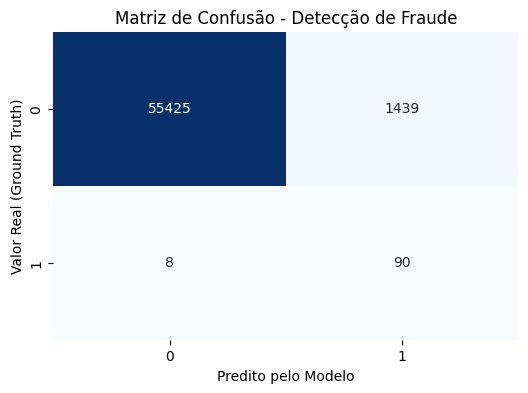

In [26]:
y_pred = model.predict(X_test)

print(f"Acurácia Geral: {accuracy_score(y_test, y_pred):.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.xlabel('Predito pelo Modelo')
plt.ylabel('Valor Real (Ground Truth)')
plt.title('Matriz de Confusão - Detecção de Fraude')
plt.show()

In [27]:
# Extraindo os valores da matriz de confusão

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

print("Resultados da Matriz de Confusão:\n")

print(f"Verdadeiros Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdadeiros Positivos (TP): {tp}")

Resultados da Matriz de Confusão:

Verdadeiros Negativos (TN): 55425
Falsos Positivos (FP): 1439
Falsos Negativos (FN): 8
Verdadeiros Positivos (TP): 90


## Análise e Conclusão

### Desbalanceamento dos dados e acurácia

A **acurácia**, quando analisada isoladamente, é uma métrica pouco adequada para problemas de detecção de fraude. Isso ocorre porque o dataset apresenta um forte desbalanceamento entre as classes: aproximadamente **99,83%** das transações são legítimas, enquanto apenas **0,17%** são fraudulentas.

Nesse cenário, um modelo que classificasse praticamente todas as transações como legítimas poderia apresentar uma acurácia muito alta, mas ainda assim seria incapaz de detectar uma parcela significativa das fraudes. Por esse motivo, métricas como **precisão (precision), recall e F1-score** são mais informativas para avaliar o desempenho do modelo.

### Análise dos erros

A **matriz de confusão** permite analisar os principais tipos de erro cometidos pelo modelo.

Os **Falsos Negativos (FN)** representam transações que realmente são fraudulentas, mas foram classificadas como legítimas. Consequentemente, essas fraudes conseguem passar pelo sistema sem serem identificadas.

Já os **Falsos Positivos (FP)** representam transações legítimas que foram classificadas incorretamente como fraudulentas. Nesse caso, o cliente pode enfrentar bloqueios, solicitações adicionais de confirmação ou outras etapas de verificação.

Em um sistema de detecção de fraude, os **Falsos Negativos geralmente possuem um custo maior para o negócio**, pois representam fraudes que não foram detectadas e podem resultar em prejuízos financeiros. Entretanto, uma quantidade excessiva de Falsos Positivos também é indesejável, pois pode prejudicar a experiência dos clientes e aumentar os custos operacionais.

### Desempenho do modelo

O modelo de **Regressão Logística** apresentou um **recall de aproximadamente 92% para a classe de fraude**, identificando 90 das 98 transações fraudulentas presentes no conjunto de teste. Dessa forma, apenas 8 fraudes foram classificadas incorretamente como transações legítimas, correspondendo aos **Falsos Negativos (FN)**.

Por outro lado, o modelo apresentou uma **precisão de aproximadamente 6% para a classe fraudulenta**. Isso está relacionado ao número elevado de **Falsos Positivos (FP)**: das 56.864 transações legítimas presentes no conjunto de teste, 1.439 foram classificadas incorretamente como fraudulentas.

Esse resultado mostra que o modelo foi configurado de forma a priorizar a **detecção de fraudes**, reduzindo a quantidade de fraudes que passam despercebidas, mas ao custo de gerar uma quantidade significativa de alertas incorretos.

Portanto, embora o recall elevado seja interessante para um sistema em que deixar uma fraude passar possui um custo elevado, a baixa precisão indica que o modelo ainda poderia ser aprimorado para reduzir os Falsos Positivos e proporcionar um melhor equilíbrio entre segurança e experiência do cliente.

### Ajuste do limiar de classificação

O modelo utiliza, por padrão, um **limiar de classificação de 0,5**. Entretanto, esse valor pode ser ajustado de acordo com as necessidades do negócio.

A **redução do limiar** tende a aumentar a quantidade de fraudes detectadas, aumentando o recall, porém pode também elevar o número de Falsos Positivos. Por outro lado, o **aumento do limiar** tende a reduzir os Falsos Positivos, mas pode aumentar o risco de que algumas fraudes não sejam identificadas.

Portanto, não existe necessariamente um único limiar ideal para todos os cenários. A escolha deve considerar o equilíbrio entre **segurança, prejuízo financeiro e experiência do cliente**.

### Conclusão

De forma geral, o experimento demonstra que, em problemas de detecção de fraude, **não basta buscar uma alta acurácia**. É necessário analisar principalmente o comportamento do modelo em relação à classe minoritária e considerar os custos associados aos diferentes tipos de erro.

A utilização de **precision, recall, F1-score e matriz de confusão**, juntamente com a possibilidade de ajustar o limiar de classificação, permite uma avaliação mais adequada do modelo e possibilita adaptá-lo às necessidades específicas de um sistema real de detecção de fraudes.